#**環境の準備**

In [15]:
!pip install transformers[ja,torch] datasets peft
import numpy as np
from pprint import pprint
from tqdm import tqdm
from collections import Counter
import matplotlib.pyplot as plt
from datasets import Dataset
from datasets import load_dataset
from transformers import AutoTokenizer
from transformers import BatchEncoding
from transformers import DataCollatorWithPadding
from transformers import AutoModelForSequenceClassification
from transformers import TrainingArguments
from transformers import Trainer
from transformers.trainer_utils import set_seed
import peft

set_seed(42)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 251.6/251.6 kB 3.5 MB/s eta 0:00:00


#**➀感情分析モデルの実装（ファインチューニング + LoRA）**

**データセットの準備**

In [2]:
train_dataset = load_dataset("llm-book/wrime-sentiment", split="train")
valid_dataset = load_dataset("llm-book/wrime-sentiment", split="validation")
pprint(train_dataset[0])
print("==========================================================================")
pprint(train_dataset.features)

/usr/local/lib/python3.10/dist-packages/huggingface_hub/utils/_token.py:89: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Generating train split:   0%|          | 0/20149 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/1608 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1781 [00:00<?, ? examples/s]

{'datetime': '2012/7/31 23:48',
 'label': 1,
 'sentence': 'ぼけっとしてたらこんな時間。チャリあるから食べにでたいのに…',
 'user_id': 1}
{'datetime': Value(dtype='string', id=None),
 'label': ClassLabel(names=['positive', 'negative'], id=None),
 'sentence': Value(dtype='string', id=None),
 'user_id': Value(dtype='int64', id=None)}


**トークン化**

In [3]:
model_name = "cl-tohoku/bert-base-japanese-v3"
tokenizer = AutoTokenizer.from_pretrained(model_name)

#トークン化の確認
tokenizer.tokenize("今日の天気は雨のち晴れです。")

tokenizer_config.json:   0%|          | 0.00/251 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/231k [00:00<?, ?B/s]

['今日', 'の', '天気', 'は', '雨', 'のち', '晴れ', 'です', '。']

In [4]:
#トークン化オブジェクトの取得
encoded_input = tokenizer('今日の天気は雨のち晴れです。')
pprint(encoded_input)
print("====================================================================================")
#idからトークンが取得できるか確認
tokenizer.convert_ids_to_tokens(encoded_input["input_ids"])

{'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
 'input_ids': [2, 15028, 464, 18834, 465, 6477, 13386, 25466, 13037, 385, 3],
 'token_type_ids': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]}


['[CLS]', '今日', 'の', '天気', 'は', '雨', 'のち', '晴れ', 'です', '。', '[SEP]']

**データセットの統計量**

100%|██████████| 20149/20149 [00:11<00:00, 1788.74it/s]


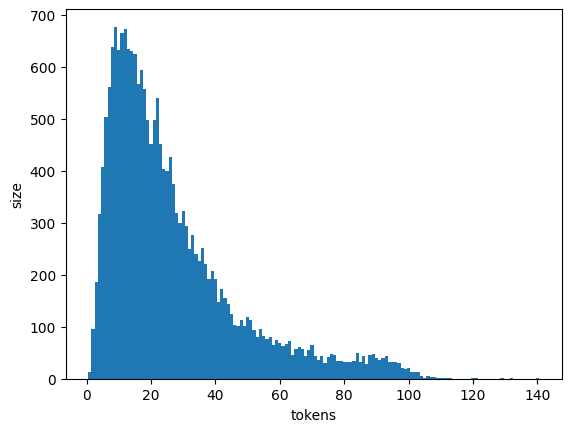

100%|██████████| 1608/1608 [00:02<00:00, 792.56it/s]


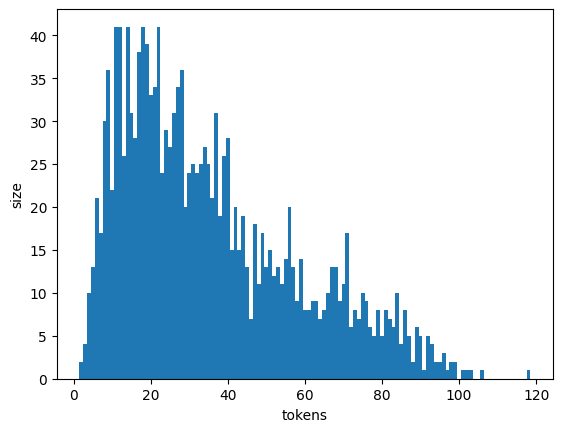

In [5]:
#トークン数の分布
def visualize_tokens(dataset):
  length_count = Counter() #keyにトークン数、valueに出現回数のdict
  for data in tqdm(dataset):
    length = len(tokenizer.tokenize(data["sentence"]))
    length_count[length] += 1 # ""がいらないので注意

  plt.bar(length_count.keys(), length_count.values(), width=1.0)
  plt.xlabel("tokens")
  plt.ylabel("size")
  plt.show()

visualize_tokens(train_dataset)
visualize_tokens(valid_dataset)

100%|██████████| 20149/20149 [00:04<00:00, 4607.07it/s]


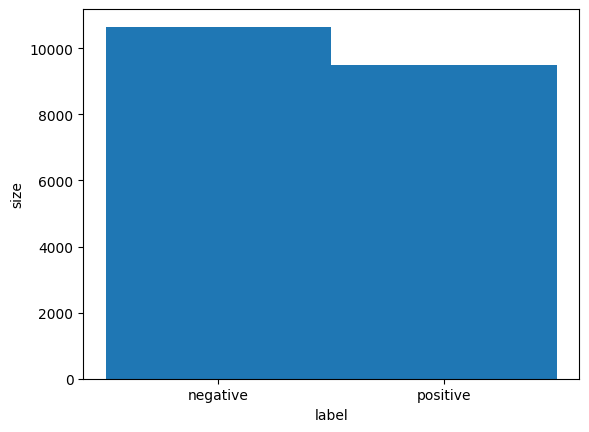

100%|██████████| 1608/1608 [00:00<00:00, 4747.91it/s]


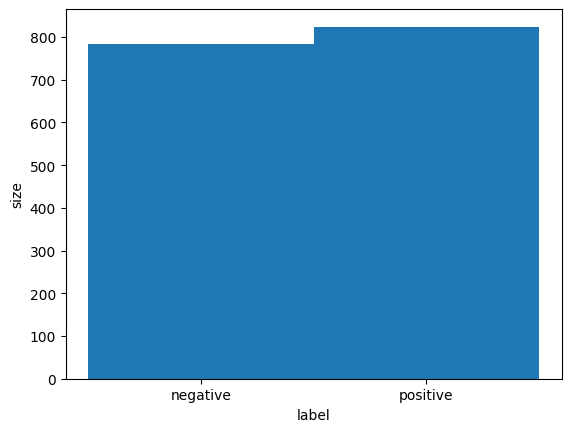

In [6]:
#ラベルの分布
def visualize_labels(dataset):
  label_count = Counter() #keyにトークン数、valueに出現回数のdict
  for data in tqdm(dataset):
    label_id = data["label"]
    label_name = dataset.features["label"].names[label_id]
    label_count[label_name] += 1

  plt.bar(label_count.keys(), label_count.values(), width=1.0)
  plt.xlabel("label")
  plt.ylabel("size")
  plt.show()

visualize_labels(train_dataset)
visualize_labels(valid_dataset)

**前処理とミニバッチ構築**

In [7]:
#前処理
def preprocess(data:dict) -> BatchEncoding: #入力値の型をdict、戻り値の型をBatchEncodingに指定
  encoded_data = tokenizer(data["sentence"], max_length=512) #トークン化とid変換
  encoded_data["labels"] = data["label"] #labelをkeyとして格納
  return encoded_data

encoded_train_dataset = train_dataset.map(preprocess, remove_columns=train_dataset.column_names)
encoded_valid_dataset = valid_dataset.map(preprocess, remove_columns=valid_dataset.column_names)

print(encoded_train_dataset)
print(encoded_train_dataset[0])

Parameter 'function'=<function preprocess at 0x78c4b144b250> of the transform datasets.arrow_dataset.Dataset._map_single couldn't be hashed properly, a random hash was used instead. Make sure your transforms and parameters are serializable with pickle or dill for the dataset fingerprinting and caching to work. If you reuse this transform, the caching mechanism will consider it to be different from the previous calls and recompute everything. This warning is only showed once. Subsequent hashing failures won't be showed.


Map:   0%|          | 0/20149 [00:00<?, ? examples/s]

Truncation was not explicitly activated but `max_length` is provided a specific value, please use `truncation=True` to explicitly truncate examples to max length. Defaulting to 'longest_first' truncation strategy. If you encode pairs of sequences (GLUE-style) with the tokenizer you can select this strategy more precisely by providing a specific strategy to `truncation`.


Map:   0%|          | 0/1608 [00:00<?, ? examples/s]

Dataset({
    features: ['input_ids', 'token_type_ids', 'attention_mask', 'labels'],
    num_rows: 20149
})
{'input_ids': [2, 478, 7139, 15269, 441, 456, 13123, 21311, 12671, 385, 12651, 7065, 12485, 12488, 13781, 461, 457, 13030, 464, 461, 29, 29, 29, 3], 'token_type_ids': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1], 'labels': 1}


In [8]:
#ミニバッチ構築
data_collator = DataCollatorWithPadding(tokenizer = tokenizer) #tokenizerに従ってデータをパディングするコレーター
batch_inputs = data_collator(encoded_train_dataset[0:4]) #取り出したデータをバッチ処理（各文の長さをそろえる＋テンソル変換）
pprint({name: tensor.size() for name, tensor in batch_inputs.items()})

{'attention_mask': torch.Size([4, 36]),
 'input_ids': torch.Size([4, 36]),
 'labels': torch.Size([4]),
 'token_type_ids': torch.Size([4, 36])}


**モデルの設定**

In [9]:
class_label = train_dataset.features["label"]
num_labels = class_label.num_classes
model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=num_labels
)

print(model.forward(**data_collator(encoded_train_dataset[0:4]))) #出力の確認

config.json:   0%|          | 0.00/472 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/447M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at cl-tohoku/bert-base-japanese-v3 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


SequenceClassifierOutput(loss=tensor(0.8075, grad_fn=<NllLossBackward0>), logits=tensor([[ 0.2869, -0.2644],
        [ 0.1715,  0.0095],
        [ 0.0040,  0.1524],
        [ 0.2233, -0.2968]], grad_fn=<AddmmBackward0>), hidden_states=None, attentions=None)


**fine tuningの実行とモデルの評価**

In [10]:
training_args = TrainingArguments(
    output_dir="output_wrime",  # 結果の保存フォルダ
    per_device_train_batch_size = 32,  # 訓練時のバッチサイズ
    per_device_eval_batch_size = 32,  # 評価時のバッチサイズ
    learning_rate = 2e-5,  # 学習率
    lr_scheduler_type = "linear",  # 学習率スケジューラの種類
    warmup_ratio = 0.1,  # 学習率のウォームアップの長さを指定
    num_train_epochs = 3,  # エポック数
    save_strategy = "epoch",  # チェックポイントの保存タイミング
    logging_strategy = "epoch",  # ロギングのタイミング
    eval_strategy = "epoch",  # 検証セットによる評価のタイミング
    load_best_model_at_end = True,  # 訓練後に開発セットで最良のモデルをロード
    metric_for_best_model ="accuracy",  # 最良のモデルを決定する評価指標
    fp16=True,  # 自動混合精度演算の有効化
)

In [11]:
def compute_accuracy(pred) -> dict[str, float]: #学習中のvalidデータに対するメトリクスを定義
  predictions, labels = pred
  predictions = np.argmax(predictions, axis = 1) #スコアが最大となっているindexを取得
  return {"accuracy": (predictions == labels).mean()}

trainer = Trainer(
    model=model,
    train_dataset=encoded_train_dataset,
    eval_dataset=encoded_valid_dataset,
    data_collator=data_collator,
    args=training_args,
    compute_metrics=compute_accuracy,
)
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy
1,0.316600,0.177949,0.928483
2,0.139700,0.183646,0.937811
3,0.071900,0.238156,0.935323


TrainOutput(global_step=1890, training_loss=0.17607763583067232, metrics={'train_runtime': 365.7939, 'train_samples_per_second': 165.249, 'train_steps_per_second': 5.167, 'total_flos': 2736880683965940.0, 'train_loss': 0.17607763583067232, 'epoch': 3.0})

In [13]:
#validデータでのモデル評価
eval_metrics = trainer.evaluate(encoded_valid_dataset)
pprint(eval_metrics)

{'epoch': 3.0,
 'eval_accuracy': 0.9378109452736318,
 'eval_loss': 0.18364641070365906,
 'eval_runtime': 1.9452,
 'eval_samples_per_second': 826.658,
 'eval_steps_per_second': 26.219}


**学習済みモデルの保存**

In [14]:
trainer.save_model('./text/model')

**LoRAによるfine tuningの実行とモデル評価**

In [21]:
#モデルの設定
class_label = train_dataset.features["label"]
num_labels = class_label.num_classes
base_model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=num_labels
)

#LoRA層の設定
peft_config = peft.LoraConfig(
    task_type = peft.TaskType.SEQ_CLS, #モデルのタスクを指定
    r = 8, #差分行列のランク
    lora_alpha = 32, #出力の調整パラメータ
    lora_dropout = 0.1,
    inference_mode = False
)

#モデルにLoRa層を追加
model = peft.get_peft_model(base_model, peft_config)

print("===========================================================================")

#学習パラメータの数とパラメータ全体からの割合
model.print_trainable_parameters()

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at cl-tohoku/bert-base-japanese-v3 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


trainable params: 296,450 || all params: 111,505,156 || trainable%: 0.2659


In [18]:
lora_trainer = Trainer(
    model=model,
    train_dataset=encoded_train_dataset,
    eval_dataset=encoded_valid_dataset,
    data_collator=data_collator,
    args=training_args,
    compute_metrics=compute_accuracy,
)
lora_trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy
1,0.586900,0.288496,0.895522
2,0.314400,0.253607,0.909826
3,0.294100,0.248802,0.910448


TrainOutput(global_step=1890, training_loss=0.3984358045789931, metrics={'train_runtime': 248.8542, 'train_samples_per_second': 242.901, 'train_steps_per_second': 7.595, 'total_flos': 2746353725336040.0, 'train_loss': 0.3984358045789931, 'epoch': 3.0})

In [22]:
eval_metrics = lora_trainer.evaluate(encoded_valid_dataset)
pprint(eval_metrics)

{'epoch': 3.0,
 'eval_accuracy': 0.9104477611940298,
 'eval_loss': 0.2488020360469818,
 'eval_runtime': 2.1273,
 'eval_samples_per_second': 755.877,
 'eval_steps_per_second': 23.974}
